In [1]:
import sys
from pathlib import Path
# import us_stock_valuation_preprocessing as stock_prep

def find_data_folder():
    """DATA 폴더 찾기"""
    current = Path.cwd()

    # 상위 5단계까지 검색
    for i in range(5):
        data_path = current / "DATA"
        if data_path.exists():
            target_files = [
                data_path / "stock_invest_function.py",
                data_path / "us_stock_valuation_preprocessing.py"
            ]
            if all(f.exists() for f in target_files):
                return data_path
        current = current.parent
    return None

def fix_and_import_modules():
    """모듈을 수정해서 import"""
    data_path = find_data_folder()
    if not data_path:
        print("DATA 폴더를 찾을 수 없습니다")
        return None, None

    sys.path.insert(0, str(data_path))
    print(f"DATA 폴더 발견: {data_path}")

    # stock_invest_function은 정상 import
    try:
        import stock_invest_function as stock_func
        print("stock_invest_function import 성공!")
    except Exception as e:
        print(f"stock_invest_function import 실패: {e}")
        stock_func = None

    # us_stock_valuation_preprocessing은 파일을 읽어서 수정 후 실행
    try:
        preprocessing_file = data_path / "us_stock_valuation_preprocessing.py"

        # 파일 내용 읽기
        with open(preprocessing_file, 'r', encoding='utf-8') as f:
            content = f.read()

        # 문제가 되는 부분을 찾아서 수정
        # "from stock_invest_function import *"를 모듈 최상위로 이동
        lines = content.split('\n')

        # import * 구문을 찾아서 제거하고 최상위에 추가
        fixed_lines = []
        import_lines = []
        inside_function = False

        for line in lines:
            # 함수 시작 감지
            if line.strip().startswith('def '):
                inside_function = True

            # import * 구문 처리
            if 'from stock_invest_function import *' in line:
                if inside_function:
                    # 함수 내부에 있으면 제거
                    continue
                else:
                    # 최상위에 있으면 그대로 유지
                    import_lines.append(line)
                    continue

            fixed_lines.append(line)

        # 수정된 내용 조합
        final_content = '\n'.join(import_lines + [''] + fixed_lines)

        # 수정된 내용을 실행해서 모듈 생성
        import types
        stock_prep = types.ModuleType('us_stock_valuation_preprocessing')

        # get_db_host 함수가 필요한 경우를 위해 미리 정의
        if stock_func and hasattr(stock_func, 'get_db_host'):
            stock_prep.get_db_host = stock_func.get_db_host
        else:
            stock_prep.get_db_host = lambda: 'localhost'

        # 수정된 코드 실행
        exec(final_content, stock_prep.__dict__)

        print("us_stock_valuation_preprocessing 수정 후 import 성공!")
        return stock_func, stock_prep

    except Exception as e:
        print(f"파일 수정 중 오류: {e}")
        return stock_func, None

# 실행
stock_func, stock_prep = fix_and_import_modules()

if stock_func and stock_prep:
    print("모든 모듈이 성공적으로 로드되었습니다!")
    print("사용 가능한 함수들:")
    if hasattr(stock_prep, 'run_data_preprocessing'):
        print("- stock_prep.run_data_preprocessing()")
    if hasattr(stock_prep, 'run_simple_preprocessing'):
        print("- stock_prep.run_simple_preprocessing()")
else:
    print("모듈 로드에 실패했습니다.")

import us_stock_valuation_preprocessing as stock_prep

DATA 폴더 발견: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA
stock_invest_function import 성공!
us_stock_valuation_preprocessing 수정 후 import 성공!
모든 모듈이 성공적으로 로드되었습니다!
사용 가능한 함수들:
- stock_prep.run_data_preprocessing()
- stock_prep.run_simple_preprocessing()


In [2]:
from stock_invest_function import *

In [3]:
api_key = 'hT0gAk87j9xZx4PlBApvBqfVL5IahvgV'

db_info = {
    'host': get_db_host(),
    'port': 3307,
    'user': 'stox7412',
    'password': 'Apt106503!~',
    'database': 'investar'
}

# 1. 먼저 디버깅으로 원인 파악
# stock_prep.debug_missing_data(result, 'AMAT', db_info)

# 기본 사용 (수출 데이터 포함)
result = stock_prep.run_enhanced_preprocessing(
    ticker='AMAT',
    api_key=api_key,
    db_info=db_info,
    hs_code='841191'  # 수출 데이터 포함 시
)

# # 간단한 사용 (수출 데이터 제외)
# result = run_simple_enhanced_preprocessing(
#     ticker='AMAT',
#     api_key='your_api_key',
#     db_info=db_info
# )

# 단일 종목 간단 버전
# result = stock_prep.run_simple_preprocessing('AAPL', api_key)

Market Cap: 100%|██████████| 1/1 [00:17<00:00, 17.17s/it]


In [4]:
result.tail(24)

,ticker,date_month_end,market_cap_billions,revenue_billions,revenue_ttm,revenue_ttm_billions,revenue_ttm_shift,PSR_ttm,hs_code_6d,expDlr,expDlr_yoy
275,AMAT,2024-10-31,147.81,7.04,27.38,27.38,26.86,5.502978,841191,247061000.0,24.201186
276,AMAT,2024-11-30,142.21,7.04,27.64,27.64,26.99,5.268989,841191,255786000.0,63.795290
277,AMAT,2024-12-31,132.38,7.04,27.90,27.90,27.38,4.834916,841191,213521000.0,-11.345056
278,AMAT,2025-01-31,146.26,7.17,28.29,28.29,27.64,5.291606,841191,248374000.0,14.966673
279,AMAT,2025-02-28,128.19,7.17,28.42,28.42,27.90,4.594624,841191,226273000.0,11.710515
280,AMAT,2025-03-31,117.69,7.17,28.55,28.55,28.29,4.160127,841191,263404000.0,19.437013
281,AMAT,2025-04-30,122.23,7.10,28.61,28.61,28.42,4.300844,841191,246104000.0,26.244082
282,AMAT,2025-05-31,127.12,7.10,28.54,28.54,28.55,4.452539,841191,278946000.0,10.581836
283,AMAT,2025-06-30,148.47,7.10,28.47,28.47,28.61,5.189444,841191,271430000.0,4.608590
284,AMAT,2025-07-31,146.03,7.30,28.60,28.60,28.54,5.116678,841191,237667000.0,33.921045


In [5]:
from sarima_forecast import sarima_forecast
from sarima_forecast import revenue_sarima_forecast_pipeline
from us_lstm_forecast import *
from us_prophet_forecast import *

In [6]:
result_data, quarterly_data, forecast_result, model_info = revenue_sarima_forecast_pipeline(
    data=result,
    revenue_col='revenue_billions',
    data_end_date='2025-08-31',
    forecast_quarters=4
)

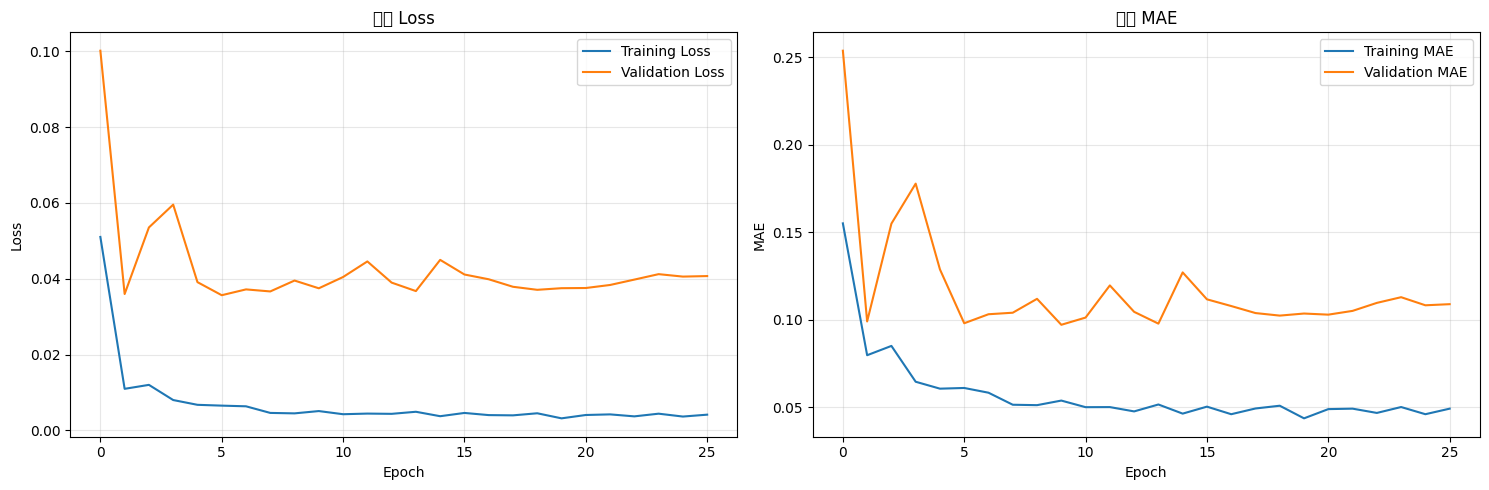

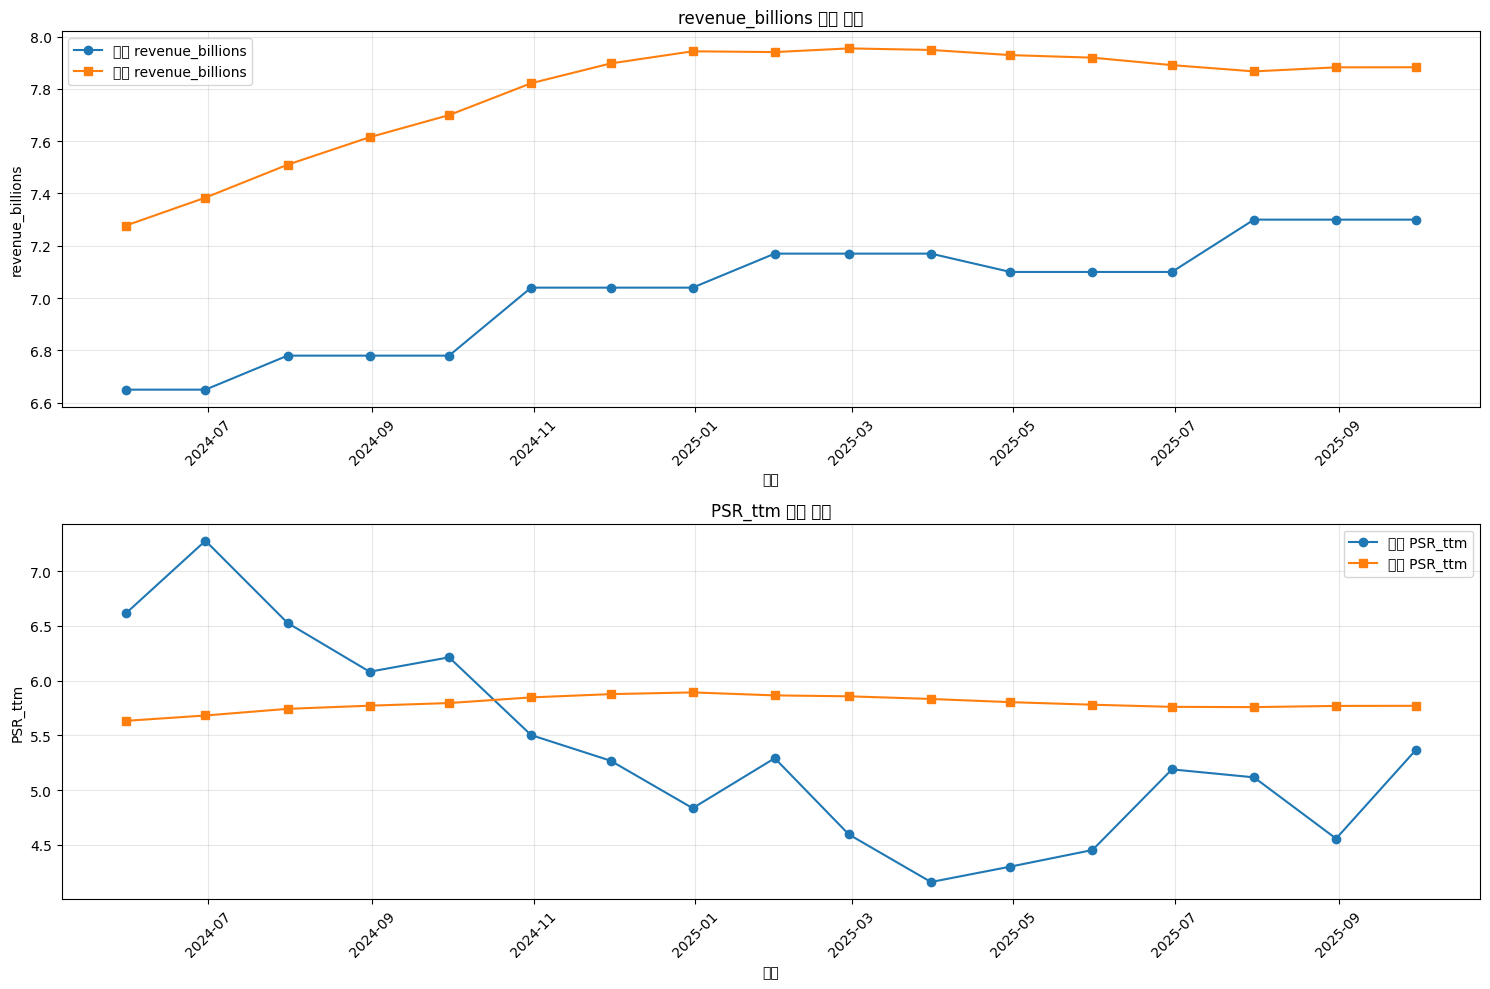

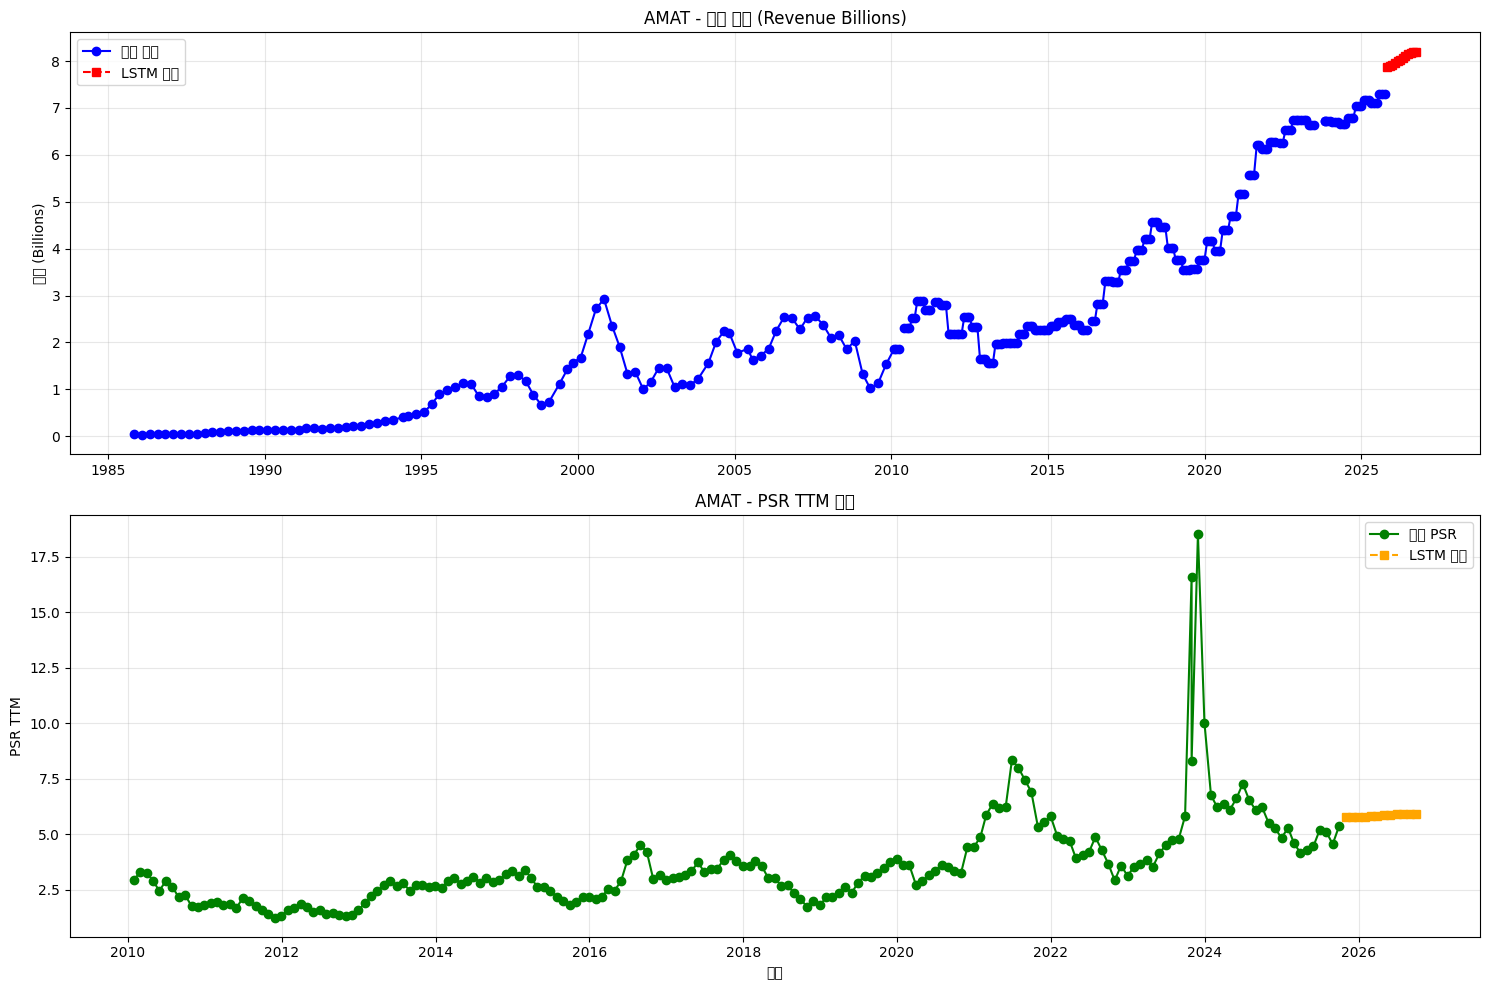

    date_month_end  revenue_billions   PSR_ttm
288     2025-10-31          7.882584  5.770484
290     2025-11-30          7.901514  5.774453
292     2025-12-31          7.925045  5.784309
294     2026-01-31          7.953208  5.798622
295     2026-02-28          7.998158  5.820877
298     2026-03-31          8.024771  5.836350
300     2026-04-30          8.066693  5.857595
302     2026-05-31          8.104604  5.875804
304     2026-06-30          8.142706  5.893498
305     2026-07-31          8.169142  5.905590
308     2026-08-31          8.184198  5.913215
310     2026-09-30          8.204085  5.922409


In [10]:
# 전처리된 데이터로 바로 예측
prediction_df, model_results = run_lstm_prediction(
    df=result,  # 앞서 전처리한 데이터
    ticker='AMAT',
    prediction_months=12,
    plot_results=True
)

# 예측 결과 확인
forecast_data = prediction_df[prediction_df['prediction_type'] == 'LSTM_forecast']
print(forecast_data[['date_month_end', 'revenue_billions', 'PSR_ttm']])

In [ ]:
# 전처리된 데이터로 Prophet 예측 수행
prediction_df, model_results = run_prophet_prediction(
    df=result,  # 앞서 전처리한 데이터
    ticker='AMAT',
    prediction_months=12,
    plot_results=True
)

# 외생변수 미사용 예측 결과
no_exog_data = prediction_df[prediction_df['data_type'] == 'prophet_no_exog']

# 외생변수 사용 예측 결과
with_exog_data = prediction_df[prediction_df['data_type'] == 'prophet_with_exog']

# 예측 요약 정보
summary = get_forecast_summary(model_results, ['revenue_billions', 'PSR_ttm'])

In [ ]:
from us_ets_forecast import *

In [ ]:
prediction_df, model_results = run_ets_prediction(
    df=preprocessed_data,
    prediction_months=12
)

# 예측 결과 확인
ets_forecasts = prediction_df[prediction_df['data_type'] == 'ets_forecast']

# 선택된 모델 정보
model_info = model_results['model_selection']

# 예측 요약
summary = get_ets_forecast_summary(model_results, ['revenue_billions', 'PSR_ttm'])

# 백테스팅 (선택사항)
validation_results = validate_ets_models(preprocessed_data, test_periods=6)